In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning for recommendations
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Configure visualizations
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

In [5]:
# Load dataset
df = pd.read_csv('netflix_titles.csv')

# Check first few rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
#data cleaning
# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].astype(str).str.strip()  # remove leading/trailing spaces

# Convert to datetime safely
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Optional: check how many invalid dates
print(f"Invalid/missing dates: {df['date_added'].isnull().sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Create a year_added column
df['year_added'] = df['date_added'].dt.year

Invalid/missing dates: 10


In [ ]:
#Below is exploratory analysis for Netflix

/var/folders/pr/x9bbmqhj4vvdd59kn44vz8zr0000gn/T/ipykernel_2407/4277237869.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


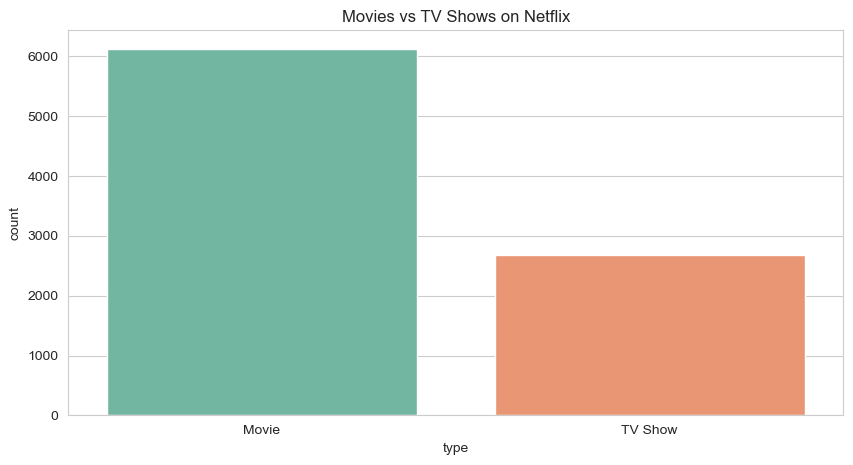

In [11]:
#Movies vs TV shows
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Movies vs TV Shows on Netflix')
plt.show()

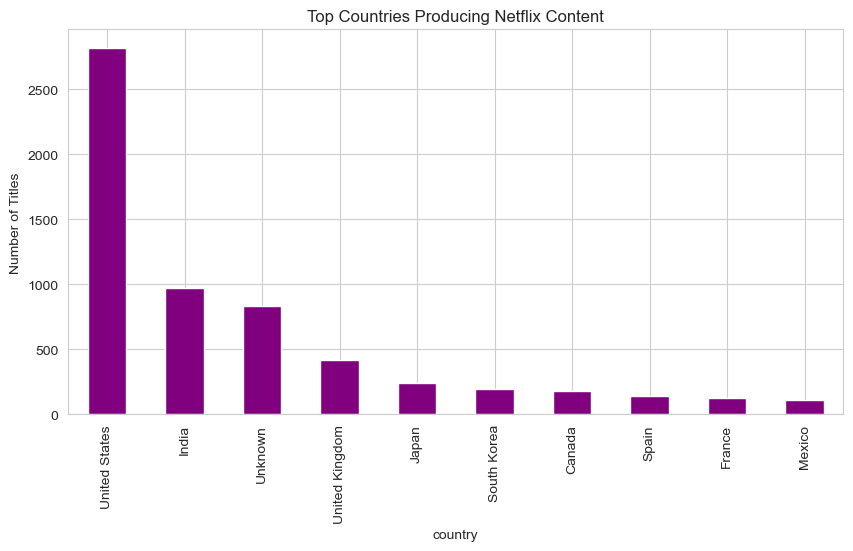

In [12]:
#top 10 countries producing content
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar', color='purple')
plt.title('Top Countries Producing Netflix Content')
plt.ylabel('Number of Titles')
plt.show()

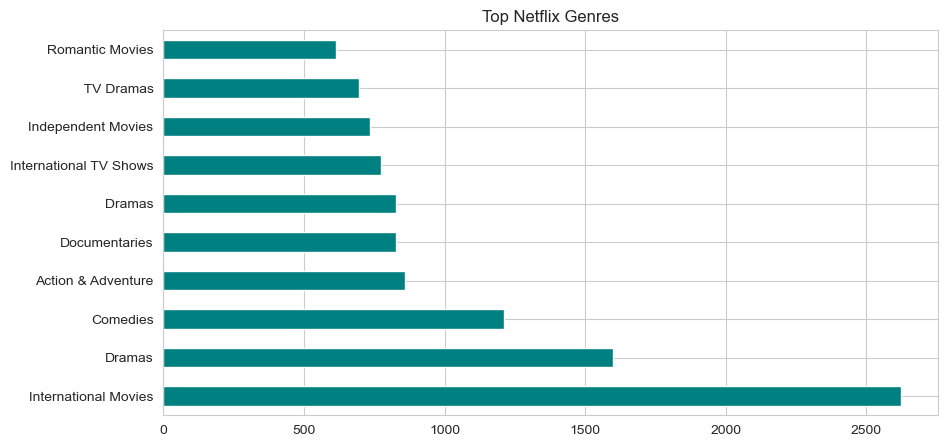

In [13]:
#top genres
genres = df['listed_in'].str.split(',', expand=True).stack()
top_genres = genres.value_counts().head(10)
top_genres.plot(kind='barh', color='teal')
plt.title('Top Netflix Genres')
plt.show()

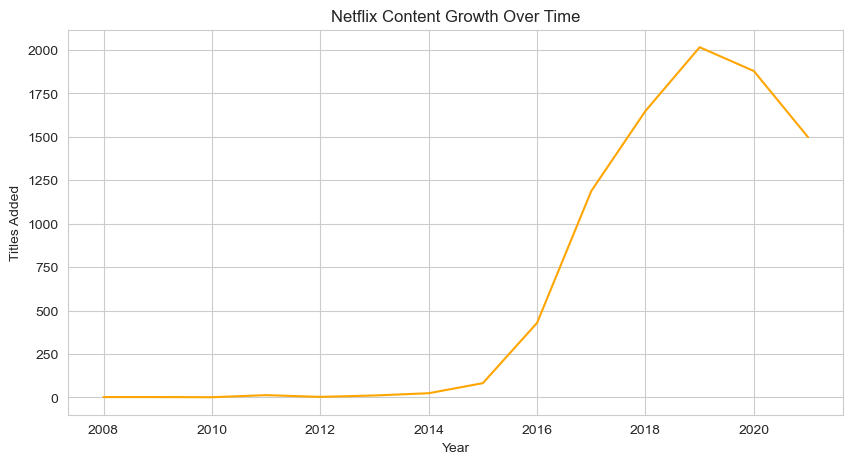

In [14]:
#netflix growth over time
content_by_year = df['year_added'].value_counts().sort_index()
content_by_year.plot(color='orange')
plt.title('Netflix Content Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.show()

/var/folders/pr/x9bbmqhj4vvdd59kn44vz8zr0000gn/T/ipykernel_2407/2691867106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='Set3')


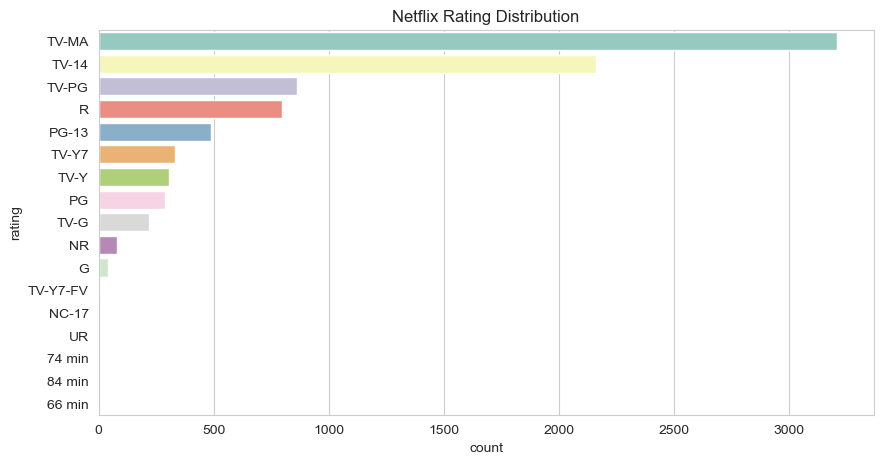

In [15]:
#ratings distributions
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='Set3')
plt.title('Netflix Rating Distribution')
plt.show()

In [ ]:
#Content-Based Recommendation System

In [16]:
# Combine genres and description into one feature
df['combined_features'] = df['listed_in'] + " " + df['description']

In [17]:
vectorizer = CountVectorizer(stop_words='english')
feature_matrix = vectorizer.fit_transform(df['combined_features'])

# Compute cosine similarity
similarity = cosine_similarity(feature_matrix)

In [18]:
def recommend(title, num_recommendations=5):
    try:
        idx = df[df['title'].str.lower() == title.lower()].index[0]
    except IndexError:
        print("Title not found. Please check spelling.")
        return
    
    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:num_recommendations+1]
    
    recommended_titles = [df.iloc[i[0]]['title'] for i in sim_scores]
    print(f"Recommendations for '{title}':")
    for t in recommended_titles:
        print("-", t)

In [19]:
recommend("Stranger Things")

Recommendations for 'Stranger Things':
- The OA
- Nightflyers
- Helix
- Star-Crossed
- Manifest
